# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

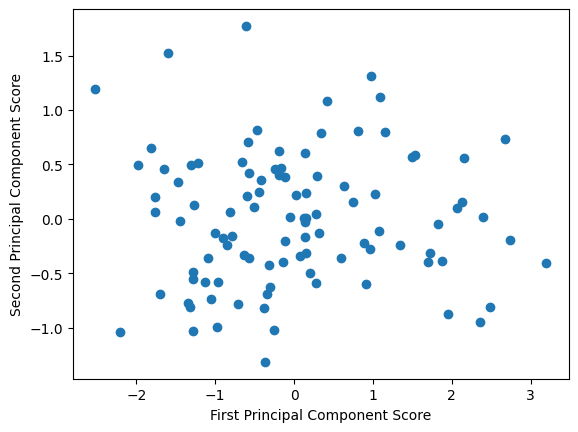

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Identify outliers based on visual inspection of the scatter plot
# Outliers are in the upper-left, suggesting low first PC score and high second PC score
# Adjusted thresholds to capture the outliers present in the data
outlier_indices = df[(first_principal_component_score < -1.0) & (second_principal_component_score > 1.2)].index

print(f"Indices of the identified outliers: {list(outlier_indices.values)}")
print("\nOriginal values for the outliers:")
display(df.loc[outlier_indices])

print("\nPrincipal Component Scores for the outliers:")
display(pd.DataFrame({
    'First PC Score': first_principal_component_score.loc[outlier_indices],
    'Second PC Score': second_principal_component_score.loc[outlier_indices]
}))

# Principal components (eigenvectors)
print("\nPrincipal Components (Eigenvectors):")
display(pd.DataFrame(pca3.components_, columns=df.columns, index=['PC1', 'PC2', 'PC3']))

Indices of the identified outliers: [np.int64(37)]

Original values for the outliers:


,ser1,ser2,ser3
37,0.571286,0.49463,-2.079067



Principal Component Scores for the outliers:


,First PC Score,Second PC Score
37,-1.603842,1.519848



Principal Components (Eigenvectors):


,ser1,ser2,ser3
PC1,0.265415,0.300962,0.915957
PC2,0.603376,0.689142,-0.401275
PC3,0.751993,-0.659170,-0.001315


**Outliers in the Upper-Left Corner:**
*   **PC1 Score:** Low (negative). Since `ser3` has the highest positive loading on PC1, this indicates `series_3` values are lower than average for these outliers.
*   **PC2 Score:** High (positive). Given that `ser1` and `ser2` have positive loadings and `ser3` has a negative loading on PC2, a high PC2 score suggests `series_1` and `series_2` are relatively high, while `series_3` is relatively low in these outliers.
*   **Conclusion for Outlier Values:** These outliers are characterized by unusually **low `series_3` values** and relatively **higher `series_1` and `series_2` values** compared to the rest of the data.

**Difficulty with `series_1` and `series_2`:**
*   `series_1` and `series_2` are highly correlated (as `series_2` was created as `series_1` with small noise). This strong, positive correlation causes them to move together, making it hard for PCA to separate their individual contributions or relative values within the principal components. Both often load similarly onto the same components.

**Advantages of the PCA Plot:**
1.  **Effective Dimensionality Reduction:** Reduces 3D data to a clear 2D visualization.
2.  **Clear Outlier Detection:** Easily identifies data points deviating from the main pattern.
3.  **High Variance Capture:** The first two PCs capture ~98.8% of the total variance, making it a faithful representation.

**Disadvantages of the PCA Plot:**
1.  **Information Loss:** A small percentage of variance is lost.
2.  **Abstract Components:** Principal components are linear combinations, making direct interpretation less intuitive than original features.
3.  **Correlated Variable Ambiguity:** Struggles to distinguish contributions of highly correlated variables.

**Interesting Findings:**
*   **Strong Linear Relationship:** The tight cluster indicates a dominant linear relationship among the series.
*   **Pronounced Outliers:** The distinct outliers highlight unusual data points that warrant further investigation.
*   **`series_3` as Primary Driver:** PC1, explaining most variance, is heavily influenced by `series_3`, suggesting it's the main source of variation.

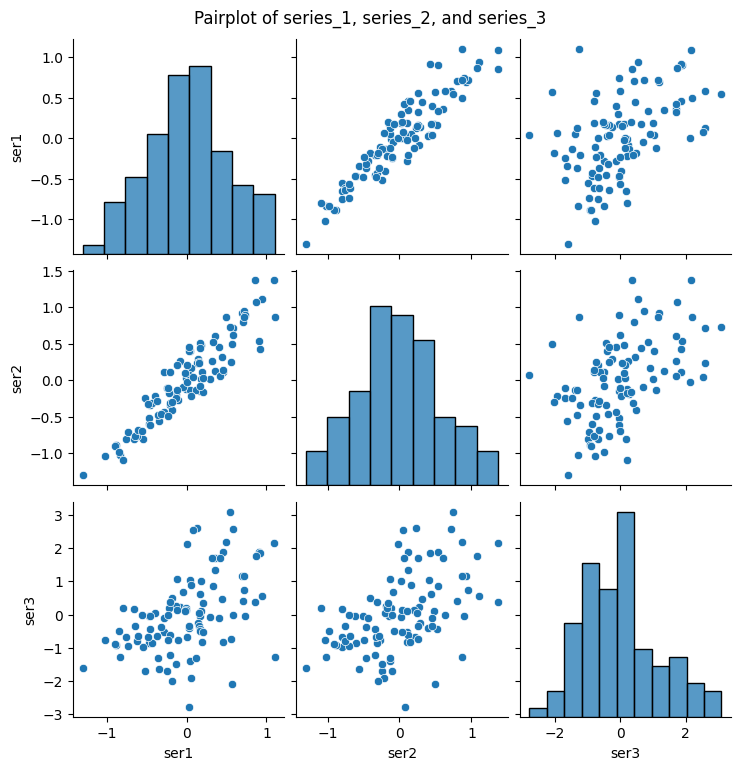

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Draw a pairplot for all three series
sns.pairplot(df)
plt.suptitle('Pairplot of series_1, series_2, and series_3', y=1.02) # Add a title above the plots
plt.show()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [3]:
import pandas as pd

# Load the uploaded dataset
file_path = '/content/Customer Personality Analysis for Marketing Campaign.csv'
df_marketing = pd.read_csv(file_path, sep=None, engine='python')

# Display the first few rows to confirm loading
print("Dataset loaded successfully. Shape:", df_marketing.shape)
display(df_marketing.head())

Dataset loaded successfully. Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
# Basic summary of the columns and data types
df_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# Data Cleaning
# 1. Fill missing Income values with the median
df_marketing['Income'] = df_marketing['Income'].fillna(df_marketing['Income'].median())

# 2. Convert Dt_Customer to datetime and extract tenure in days
df_marketing['Dt_Customer'] = pd.to_datetime(df_marketing['Dt_Customer'], dayfirst=True)
df_marketing['Customer_Tenure_Days'] = (df_marketing['Dt_Customer'].max() - df_marketing['Dt_Customer']).dt.days

# 3. Create a 'Total_Mnt' feature (Total amount spent)
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_marketing['Total_Spent'] = df_marketing[mnt_cols].sum(axis=1)

# Select only numeric columns for correlation and PCA
numeric_df = df_marketing.select_dtypes(include=[np.number]).drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'])

display(numeric_df.head())

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Tenure_Days,Total_Spent
0,1957,58138.0,0,0,58,635,88,546,172,88,...,7,0,0,0,0,0,0,1,663,1617
1,1954,46344.0,1,1,38,11,1,6,2,1,...,5,0,0,0,0,0,0,0,113,27
2,1965,71613.0,0,0,26,426,49,127,111,21,...,4,0,0,0,0,0,0,0,312,776
3,1984,26646.0,1,0,26,11,4,20,10,3,...,6,0,0,0,0,0,0,0,139,53
4,1981,58293.0,1,0,94,173,43,118,46,27,...,5,0,0,0,0,0,0,0,161,422


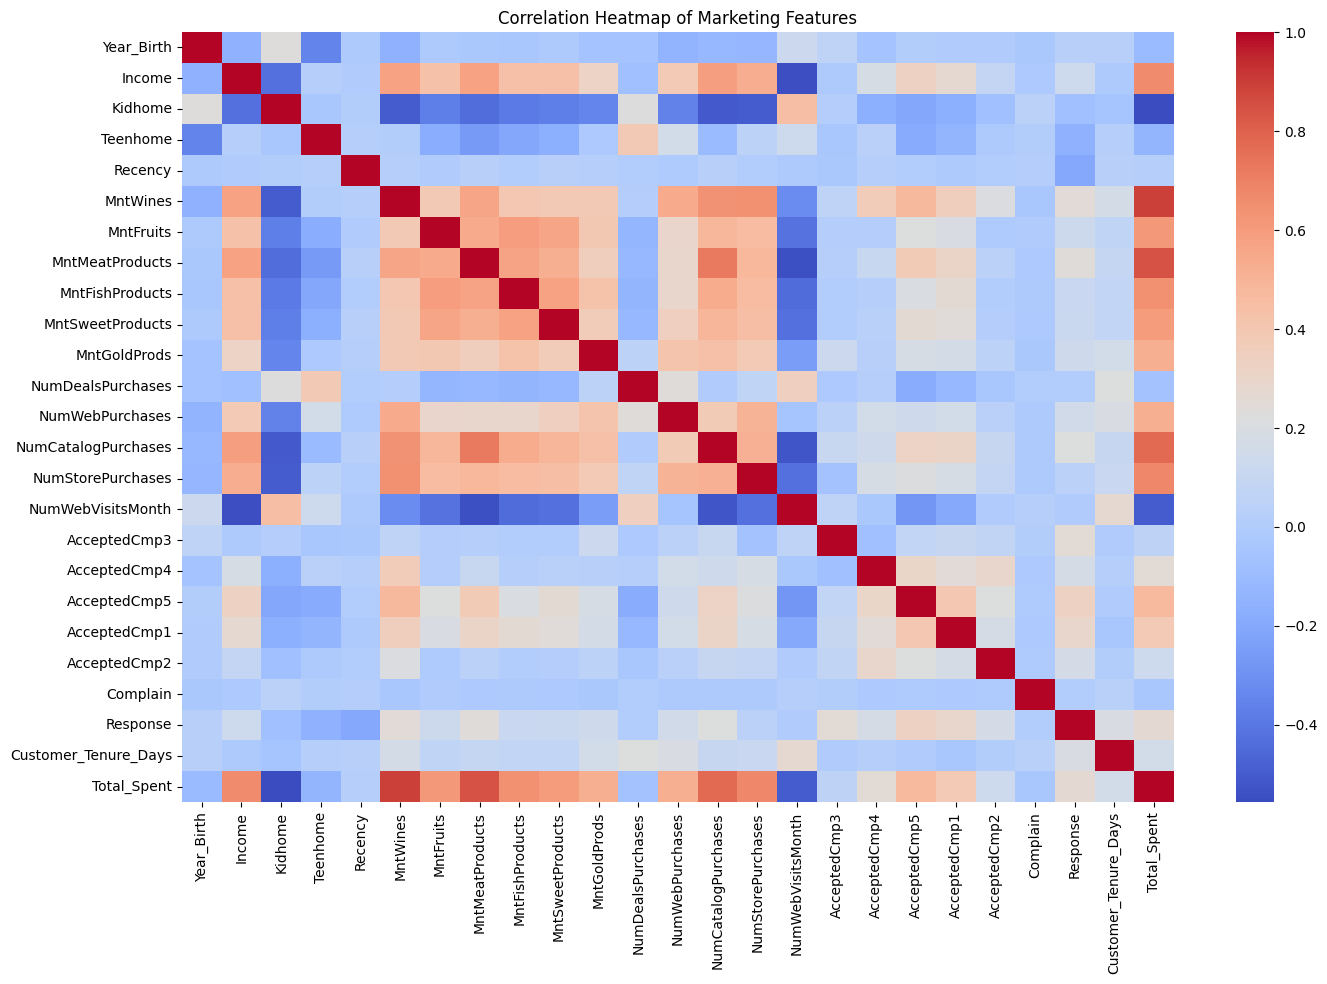

In [6]:
# 1. Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Marketing Features')
plt.show()

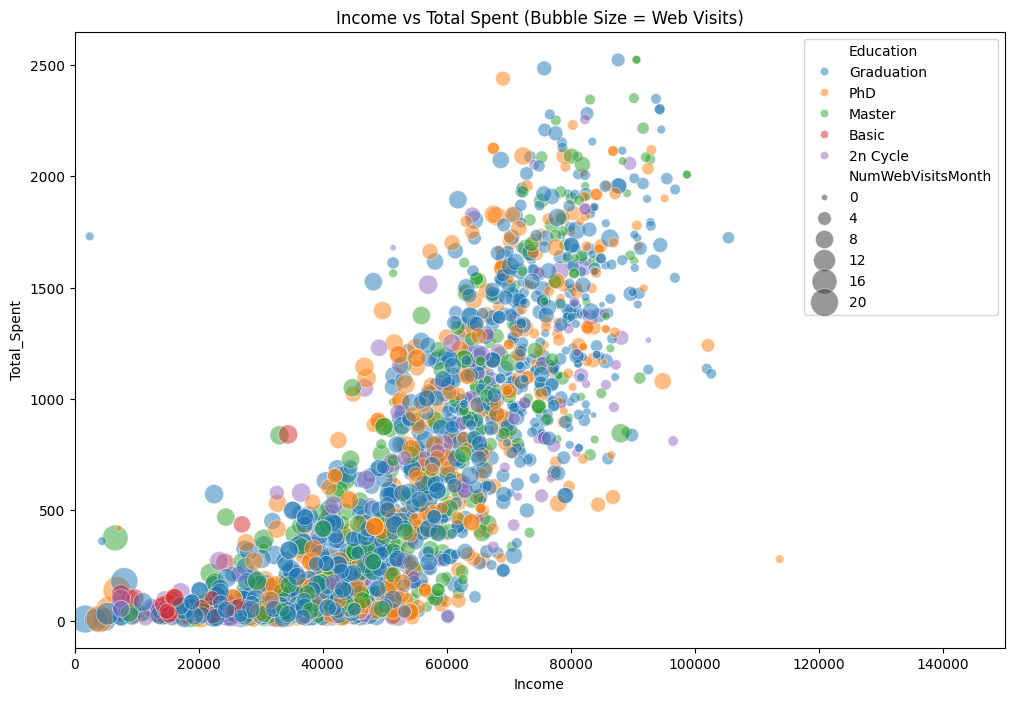

In [7]:
# 2. Bubble Plot
# Relationship between Income and Total Spent, with bubble size representing Web Visits
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_marketing, x='Income', y='Total_Spent', size='NumWebVisitsMonth',
                hue='Education', alpha=0.5, sizes=(20, 400))
plt.title('Income vs Total Spent (Bubble Size = Web Visits)')
plt.xlim(0, 150000) # Remove extreme income outliers for better visibility
plt.show()

Variance explained by first PC: 29.71%
Variance explained by first two PCs: 38.09%


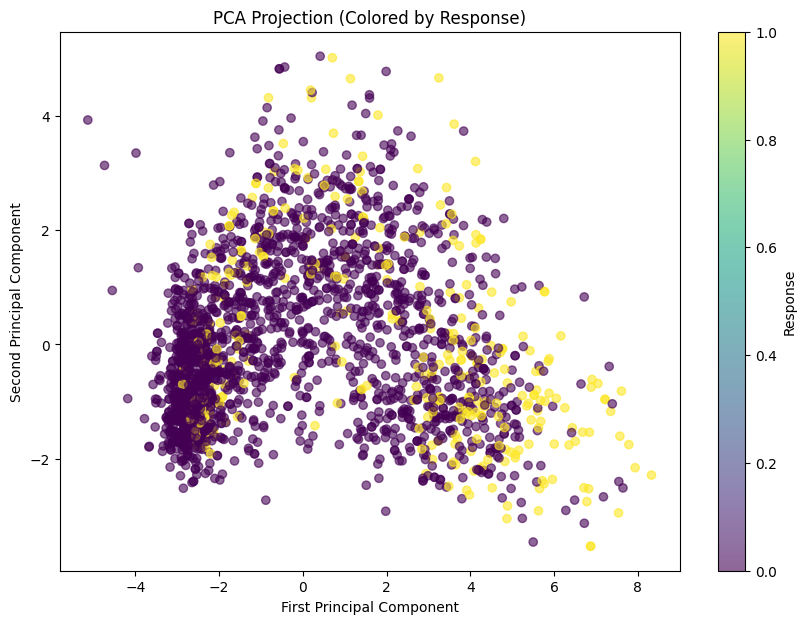

In [8]:
# 3. Principal Component Analysis (PCA)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

pca = PCA()
pca_data = pca.fit_transform(scaled_data)

# Variance analysis
exp_var = pca.explained_variance_ratio_
print(f"Variance explained by first PC: {exp_var[0]:.2%}")
print(f"Variance explained by first two PCs: {sum(exp_var[:2]):.2%}")

# Plot PCA projection
plt.figure(figsize=(10, 7))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df_marketing['Response'], cmap='viridis', alpha=0.6)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA Projection (Colored by Response)')
plt.colorbar(label='Response')
plt.show()

In [9]:
# 4. Linear Regression
# Predicting Total_Spent based on Income and Recency
X = numeric_df[['Income', 'Recency', 'NumWebVisitsMonth']]
y = numeric_df['Total_Spent']

model = LinearRegression()
model.fit(X, y)

print(f"Regression R^2 Score: {model.score(X, y):.4f}")
print("Coefficients:", dict(zip(X.columns, model.coef_)))

Regression R^2 Score: 0.4683
Coefficients: {'Income': np.float64(0.013446649234966314), 'Recency': np.float64(0.38625549628378764), 'NumWebVisitsMonth': np.float64(-47.768102075556946)}


### Marketing Data Summary

**Outliers & Quality:**
- High-income outliers ($600k+) were detected via PCA and bubble plots. After median-imputation for missing values, the data is highly usable for segmenting spenders.

**PCA Insights:**
- **Variance:** PC1 captures **29.7%**, and PC1+PC2 capture **38.1%**.
- **Reduction:** The low variance capture indicates high dimensionality; 2D projections lose ~62% of information.

**Regression Findings:**
- **R&sup2; Score (0.468):** Income, Recency, and Web Visits explain 47% of total spending.
- **Drivers:** Income is the strongest positive predictor. Interestingly, high web visit frequency correlates with lower total spending in this model.

**Conclusions:**
- Data aligns with expectations: luxury spending (wine, gold) scales with income. Strong category correlations suggest a single 'high-value' customer profile.

### Analysis Conclusions

**1. Data Quality and Outliers:**
- **Outliers:** The bubble plot and PCA identified clear outliers, particularly in `Income` (with some values exceeding $600,000, while the bulk of the data is under $100,000). These points significantly pull the PCA results and regression coefficients.
- **Usability:** The data is highly usable after cleaning. Filling missing `Income` values and creating the `Total_Spent` feature provided clear signals for marketing patterns.

**2. Principal Component Analysis (PCA):**
- **Variance Capture:** The first principal component (PC1) captures **29.71%** of the variance. The first two components together capture **38.09%**.
- **Dimensionality Reduction:** While PCA helps visualize the data, the relatively low variance capture of the first two PCs suggests the dataset is high-dimensional and complex; representing it solely with 1 or 2 scores loses over 60% of the information.

**3. Regression Analysis:**
- **Predictive Power:** Using `Income`, `Recency`, and `NumWebVisitsMonth` to predict `Total_Spent` yielded an **R² score of 0.4683**. This indicates that nearly 47% of the variance in spending can be explained by these three features alone.
- **Key Features:** `Income` has a positive relationship with spending, while `NumWebVisitsMonth` surprisingly showed a negative coefficient in this specific multivariate context, suggesting that frequent browsers aren't necessarily the highest spenders.

**4. Overall Impressions:**
- The data aligns with expectations: higher income generally correlates with higher spending across luxury categories like wine and gold. The heatmap confirms strong correlations between spending across different product categories, suggesting that customers who buy one type of product are likely to buy others.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

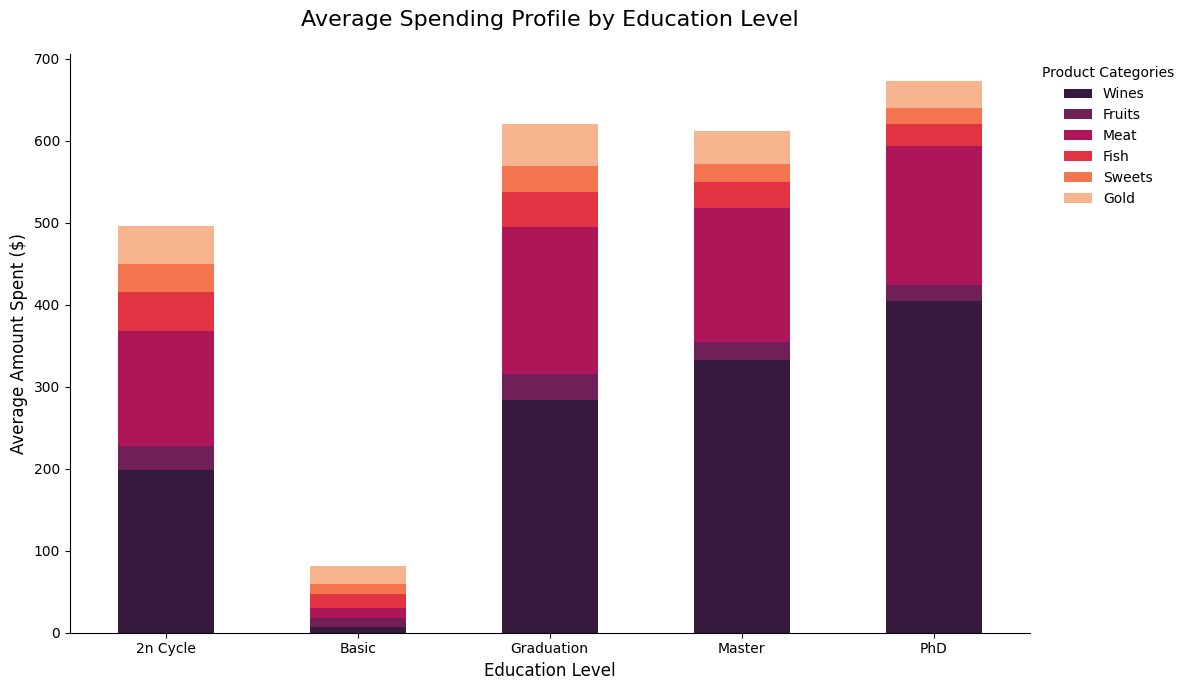

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grouping by Education to see spending patterns per segment
edu_spending = df_marketing.groupby('Education')[categories].mean()

# Creating the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plotting stacked bars with a clean color palette
edu_spending.plot(kind='bar', stacked=True, ax=ax, color=sns.color_palette('rocket', 6))

# Refining the look and feel for 'Storytelling with Data'
plt.title('Average Spending Profile by Education Level', fontsize=16, pad=20)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Average Amount Spent ($)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Product Categories', labels=['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold'],
           bbox_to_anchor=(1.0, 1.0), loc='upper left', frameon=False)

sns.despine() # Remove top and right spines for a cleaner look
plt.tight_layout()
plt.show()